
# Learnable Metric — Smoke Test

This notebook runs a few **basic checks** for the learnable inverse-metric optimizers added under `optimisers/`:

- PyTorch: `optimisers/torch_learnable.py` → `SGDLearnableDiag` (plain and log-loss modes)
- JAX/Optax: `optimisers/jax_learnable.py` → `custom_sgd_learnable_diag`, `custom_sgd_log_learnable_diag`

It:
1. Trains small linear models on synthetic data to confirm losses decrease.
2. Verifies the **metric parameters** `log_diag (s)` actually move away from zero (learnable metric engages).
3. (If available) runs a **parity sanity check** using `optimisers/compare_learnable.py`.

> Note: You mentioned the repo files were renamed: `torch_imp → torch_fixed`, `jax_imp → jax_fixed`, `compare → compare_fixed`.  
> This notebook **only depends on the new learnable files**; the "fixed" baselines are optional and not required here.


In [10]:

# Environment checks (versions + availability)
import sys, importlib

def _try_import(name):
    try:
        mod = importlib.import_module(name)
        print(f"OK: {name} {getattr(mod, '__version__', '')}")
        return True
    except Exception as e:
        print(f"Missing/failed import: {name} -> {e}")
        return False

print("Python", sys.version)

has_torch = _try_import("torch")
has_jax = _try_import("jax")
if has_jax:
    import jax
    import jax.numpy as jnp
    import optax
    print("Devices:", jax.devices())
    
# Optimisers (learnable variants)
learnable_torch_ok = _try_import("optimisers.torch_learnable")
learnable_jax_ok = _try_import("optimisers.jax_learnable")

# Optional parity check module
_ = _try_import("optimisers.compare_learnable")


Python 3.11.14 | packaged by conda-forge | (main, Oct 22 2025, 22:56:31) [Clang 19.1.7 ]
OK: torch 2.9.1
OK: jax 0.8.0
Devices: [CpuDevice(id=0)]
OK: optimisers.torch_learnable 
OK: optimisers.jax_learnable 
OK: optimisers.compare_learnable 


In [11]:

# ======================
# PyTorch experiment
# ======================
import math, time
import numpy as np

if 'torch' in sys.modules:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from optimisers.torch_learnable import SGDLearnableDiag

def make_synth_regression(n=512, d=10, noise=0.05, seed=0):
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(n, d)).astype(np.float32)
    w_true = rng.normal(size=(d, 1)).astype(np.float32)
    b_true = rng.normal(size=(1,)).astype(np.float32)
    y = X @ w_true + b_true + noise * rng.normal(size=(n, 1)).astype(np.float32)
    return X, y, w_true, b_true

class TinyLinear(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.lin = nn.Linear(d_in, d_out)
    def forward(self, x):
        return self.lin(x)

def run_torch_learnable(log_loss=False, steps=100, lr=0.05, seed=0, metric_lr=1e-3):
    assert 'torch' in sys.modules, "PyTorch not available"
    X, y, *_ = make_synth_regression(n=1024, d=10, noise=0.05, seed=seed)
    X = torch.tensor(X)
    y = torch.tensor(y)

    model = TinyLinear(10, 1)
    opt = SGDLearnableDiag(
        model.parameters(),
        lr=lr, momentum=0.9,
        xi=0.1, beta=0.8,
        weight_decay=0.0,
        metric_lr=metric_lr, metric_reg=1e-4,
        metric_clip=4.0,
        log_loss=log_loss,
    )

    hist = {"loss": [], "s_mean": [], "s_std": []}

    for t in range(steps):
        model.train()
        opt.zero_grad(set_to_none=True)
        pred = model(X)
        loss = F.mse_loss(pred, y)
        loss.backward()
        if log_loss:
            opt.step(loss=float(loss.item()))
        else:
            opt.step()
        hist["loss"].append(float(loss.item()))

        # Inspect per-param log_diag (s); concatenate all to match JAX behavior
        s_all = []
        for p in model.parameters():
            st = opt.state[p]
            s = st.get("log_diag", None)
            if s is not None:
                s_all.append(s.detach().cpu().flatten())
        if s_all:
            s_cat = torch.cat(s_all)
            hist["s_mean"].append(float(s_cat.mean().item()))
            hist["s_std"].append(float(s_cat.std().item()))
        else:
            hist["s_mean"].append(0.0)
            hist["s_std"].append(0.0)

    return hist, model


Running PyTorch — learnable metric (plain f(L)=L)...
Final loss (plain): 0.002550688339397311
Final s_mean/std (plain): 6.773255289971303e-10 0.14229708909988403


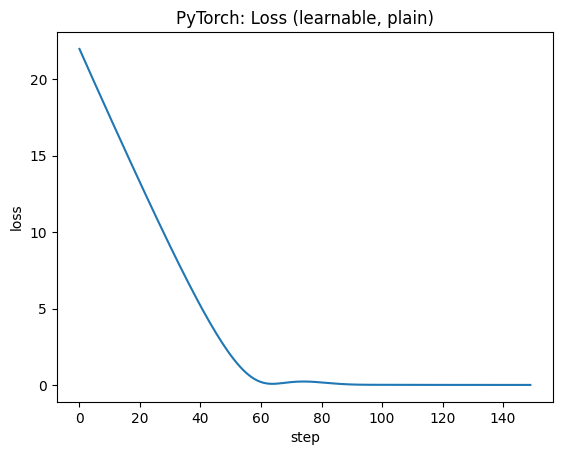

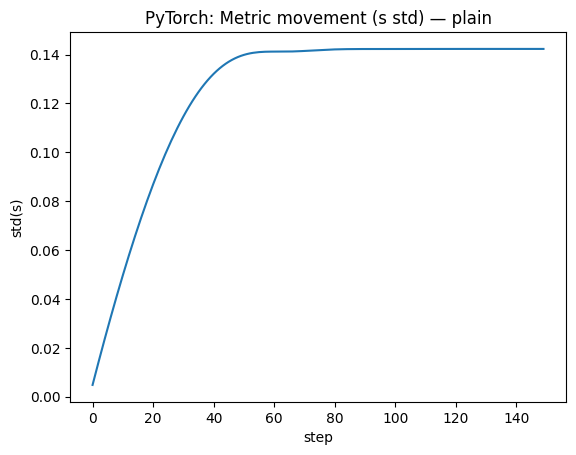

Running PyTorch — learnable metric (log-loss f(L)=log L)...
Final loss (log-loss): 0.005384685471653938
Final s_mean/std (log-loss): 0.0 0.19443024694919586


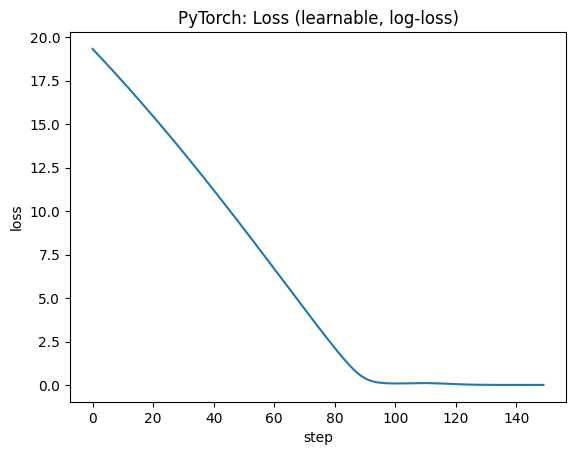

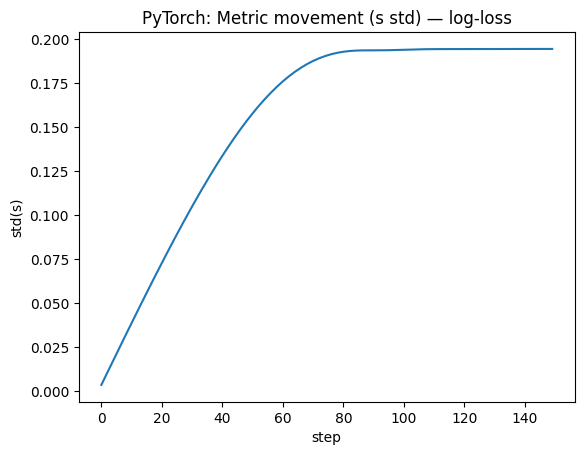

In [12]:

# Run PyTorch experiments (if available)
if 'torch' in sys.modules and learnable_torch_ok:
    import matplotlib.pyplot as plt

    print("Running PyTorch — learnable metric (plain f(L)=L)...")
    h_plain, model_plain = run_torch_learnable(log_loss=False, steps=150, lr=0.05, seed=0, metric_lr=5e-4)
    print("Final loss (plain):", h_plain["loss"][-1])
    print("Final s_mean/std (plain):", h_plain["s_mean"][-1], h_plain["s_std"][-1])

    plt.figure()
    plt.plot(h_plain["loss"])
    plt.title("PyTorch: Loss (learnable, plain)")
    plt.xlabel("step"); plt.ylabel("loss")
    plt.show()

    plt.figure()
    plt.plot(h_plain["s_std"])
    plt.title("PyTorch: Metric movement (s std) — plain")
    plt.xlabel("step"); plt.ylabel("std(s)")
    plt.show()

    print("Running PyTorch — learnable metric (log-loss f(L)=log L)...")
    h_log, model_log = run_torch_learnable(log_loss=True, steps=150, lr=0.05, seed=1, metric_lr=5e-4)
    print("Final loss (log-loss):", h_log["loss"][-1])
    print("Final s_mean/std (log-loss):", h_log["s_mean"][-1], h_log["s_std"][-1])

    plt.figure()
    plt.plot(h_log["loss"])
    plt.title("PyTorch: Loss (learnable, log-loss)")
    plt.xlabel("step"); plt.ylabel("loss")
    plt.show()

    plt.figure()
    plt.plot(h_log["s_std"])
    plt.title("PyTorch: Metric movement (s std) — log-loss")
    plt.xlabel("step"); plt.ylabel("std(s)")
    plt.show()
else:
    print("PyTorch learnable optimisers not available — skipping.")


In [13]:
# Debug: Check PyTorch s_std values
if 'torch' in sys.modules and learnable_torch_ok:
    print("Debug - PyTorch plain s_std values (first 10):", h_plain["s_std"][:10])
    print("Debug - PyTorch plain s_std values (last 10):", h_plain["s_std"][-10:])
    print("Debug - PyTorch log s_std values (first 10):", h_log["s_std"][:10])
    print("Debug - PyTorch log s_std values (last 10):", h_log["s_std"][-10:])

Debug - PyTorch plain s_std values (first 10): [0.004836680367588997, 0.009614650160074234, 0.014332215301692486, 0.018987642601132393, 0.023579174652695656, 0.02810501679778099, 0.03256336227059364, 0.036952368915081024, 0.041270192712545395, 0.04551496356725693]
Debug - PyTorch plain s_std values (last 10): [0.1422968953847885, 0.1422969400882721, 0.14229696989059448, 0.14229699969291687, 0.14229702949523926, 0.14229704439640045, 0.14229705929756165, 0.14229707419872284, 0.14229707419872284, 0.14229708909988403]
Debug - PyTorch log s_std values (first 10): [0.003537505166605115, 0.00707302987575531, 0.010605905205011368, 0.014135428704321384, 0.01766088232398033, 0.021181518211960793, 0.024696562439203262, 0.028205227106809616, 0.031706683337688446, 0.0352000892162323]
Debug - PyTorch log s_std values (last 10): [0.19442158937454224, 0.19442252814769745, 0.19442373514175415, 0.19442513585090637, 0.1944265365600586, 0.19442781805992126, 0.19442884624004364, 0.19442959129810333, 0.1944

In [14]:

# ======================
# JAX / Optax experiment
# ======================
if 'jax' in sys.modules and learnable_jax_ok:
    import jax
    import jax.numpy as jnp
    import optax
    from optimisers.jax_learnable import (
        custom_sgd_learnable_diag,
        custom_sgd_log_learnable_diag,
    )

def make_synth_regression_jax(n=1024, d=10, noise=0.05, seed=0):
    import numpy as np
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(n, d)).astype(np.float32)
    w_true = rng.normal(size=(d, 1)).astype(np.float32)
    b_true = rng.normal(size=(1,)).astype(np.float32)
    y = X @ w_true + b_true + noise * rng.normal(size=(n, 1)).astype(np.float32)
    return jnp.array(X), jnp.array(y)

def reduce_tree_mean_std(tree):
    import jax
    import jax.numpy as jnp
    leaves = jax.tree_util.tree_leaves(tree)
    if not leaves:
        return 0.0, 0.0
    cat = jnp.concatenate([x.reshape(-1) for x in leaves])
    return float(jnp.mean(cat)), float(jnp.std(cat))

def run_jax_learnable(variant="plain", steps=150, lr=0.05, seed=0, metric_lr=5e-4):
    assert 'jax' in sys.modules, "JAX not available"
    key = jax.random.PRNGKey(seed)
    X, y = make_synth_regression_jax(n=1024, d=10, noise=0.05, seed=seed)

    # params: simple linear model
    params = {
        "w": jax.random.normal(key, (10, 1)) * 0.1,
        "b": jnp.zeros((1,))
    }

    def forward(p, x):
        return x @ p["w"] + p["b"]

    def mse_loss(p):
        pred = forward(p, X)
        return jnp.mean((pred - y) ** 2)

    if variant == "plain":
        opt = custom_sgd_learnable_diag(
            learning_rate=lr, momentum=0.9, xi=0.1, beta=0.8,
            weight_decay=0.0, metric_lr=metric_lr, metric_reg=1e-4, metric_clip=4.0
        )
        state = opt.init(params)

        @jax.jit
        def one_step(p, st):
            l, g = jax.value_and_grad(mse_loss)(p)
            updates, st2 = opt.update(g, st, params=p)
            p2 = optax.apply_updates(p, updates)
            return p2, st2, l

        losses, s_means, s_stds = [], [], []
        for _ in range(steps):
            params, state, lossv = one_step(params, state)
            losses.append(float(lossv))
            sm, ss = reduce_tree_mean_std(state.log_diag)
            s_means.append(sm); s_stds.append(ss)

    else:
        opt = custom_sgd_log_learnable_diag(
            learning_rate=lr, momentum=0.9, xi=0.1, beta=0.8,
            weight_decay=0.0, metric_lr=metric_lr, metric_reg=1e-4, metric_clip=4.0
        )
        state = opt.init(params)

        @jax.jit
        def one_step(p, st):
            l, g = jax.value_and_grad(mse_loss)(p)
            updates, st2 = opt.update(g, st, l, params=p)
            p2 = optax.apply_updates(p, updates)
            return p2, st2, l

        losses, s_means, s_stds = [], [], []
        for _ in range(steps):
            params, state, lossv = one_step(params, state)
            losses.append(float(lossv))
            sm, ss = reduce_tree_mean_std(state.log_diag)
            s_means.append(sm); s_stds.append(ss)

    return {"loss": losses, "s_mean": s_means, "s_std": s_stds}, params


Running JAX — learnable metric (plain f(L)=L)...


Final loss (plain): 0.0025607820134609938
Final s_mean/std (plain): -1.3546510579942606e-09 0.14440719783306122


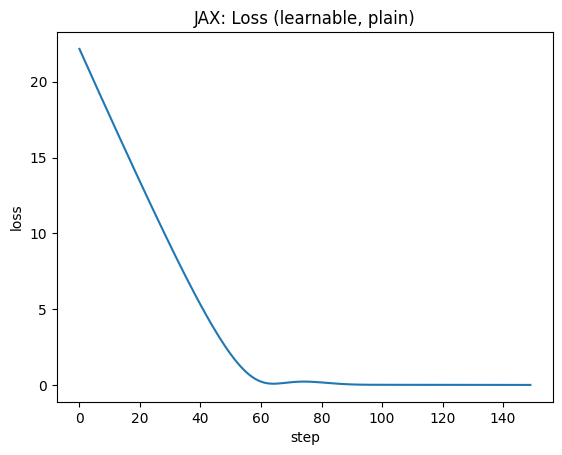

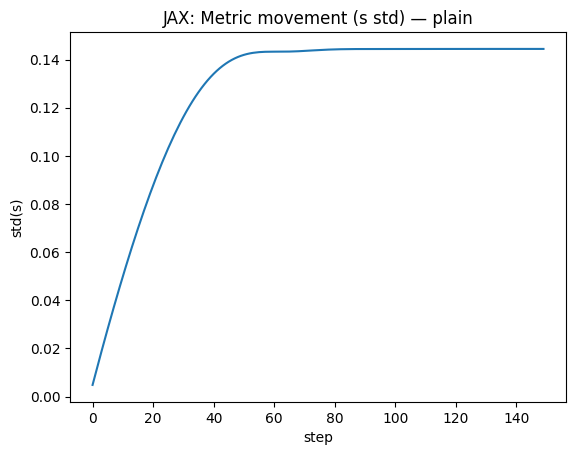

Running JAX — learnable metric (log-loss f(L)=log L)...
Final loss (log-loss): 0.004514820873737335
Final s_mean/std (log-loss): 6.773255289971303e-09 0.1530780792236328
Final loss (log-loss): 0.004514820873737335
Final s_mean/std (log-loss): 6.773255289971303e-09 0.1530780792236328


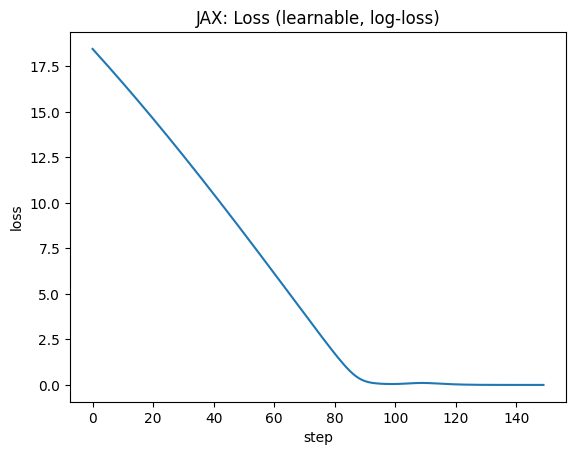

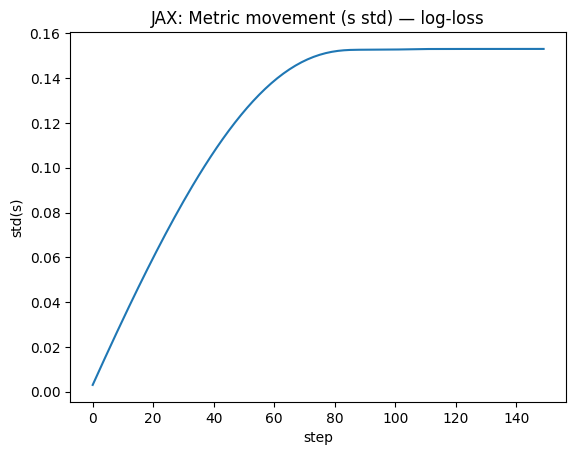

In [15]:

# Run JAX experiments (if available)
if 'jax' in sys.modules and learnable_jax_ok:
    import matplotlib.pyplot as plt

    print("Running JAX — learnable metric (plain f(L)=L)...")
    hj_plain, params_plain = run_jax_learnable(variant="plain", steps=150, lr=0.05, seed=0, metric_lr=5e-4)
    print("Final loss (plain):", hj_plain["loss"][-1])
    print("Final s_mean/std (plain):", hj_plain["s_mean"][-1], hj_plain["s_std"][-1])

    plt.figure()
    plt.plot(hj_plain["loss"])
    plt.title("JAX: Loss (learnable, plain)")
    plt.xlabel("step"); plt.ylabel("loss")
    plt.show()

    plt.figure()
    plt.plot(hj_plain["s_std"])
    plt.title("JAX: Metric movement (s std) — plain")
    plt.xlabel("step"); plt.ylabel("std(s)")
    plt.show()

    print("Running JAX — learnable metric (log-loss f(L)=log L)...")
    hj_log, params_log = run_jax_learnable(variant="log", steps=150, lr=0.05, seed=1, metric_lr=5e-4)
    print("Final loss (log-loss):", hj_log["loss"][-1])
    print("Final s_mean/std (log-loss):", hj_log["s_mean"][-1], hj_log["s_std"][-1])

    plt.figure()
    plt.plot(hj_log["loss"])
    plt.title("JAX: Loss (learnable, log-loss)")
    plt.xlabel("step"); plt.ylabel("loss")
    plt.show()

    plt.figure()
    plt.plot(hj_log["s_std"])
    plt.title("JAX: Metric movement (s std) — log-loss")
    plt.xlabel("step"); plt.ylabel("std(s)")
    plt.show()
else:
    print("JAX learnable optimisers not available — skipping.")


In [16]:

# Optional: quick parity sanity check (if the module exists in your tree)
try:
    from optimisers.compare_learnable import main as compare_main
    print("Running compare_learnable.main()...")
    compare_main()
except Exception as e:
    print("compare_learnable not available or failed to run:", e)


Running compare_learnable.main()...
max|diff w1|: 2.384185791015625e-07
max|diff b1|: 1.1920928955078125e-07



## What to look for

- **Loss curves** should trend downward for both plain and log-loss variants.
- The **metric movement** plots (`std(s)`) should rise above ~0 quickly, confirming the
  learnable inverse-metric parameters `log_diag` are adapting rather than staying at 0.
- If `compare_learnable` is present, the **max abs diffs** between JAX and PyTorch
  single-step updates should be small (on the order of 1e-6 to 1e-4 depending on device).

## Tips

- If the learnable metric seems too aggressive or unstable, reduce `metric_lr` by 10×.
- For a stronger effect, increase `xi` mildly (e.g., 0.2) and/or run for more steps.
- To test the log-loss embedding on classification, swap the toy regression for a tiny
  logistic regression and feed the scalar loss to the optimizers.
